In [3]:
# Because the project is completed within a day, I will process it in 10‑minute blocks instead of date blocks.
# The method of processing the data is the same as the requirements of this assignment.
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
base_temperature = 10
df = pd.read_csv('temperature.csv')

In [5]:
df.head()

,Time,Temperature (C),Moisture (%)
0,19:47:50 12/04/2026,26.81,44.0
1,19:47:52 12/04/2026,26.75,45.0
2,19:47:54 12/04/2026,26.69,47.0
3,19:47:56 12/04/2026,26.62,45.0
4,19:47:58 12/04/2026,26.56,44.0


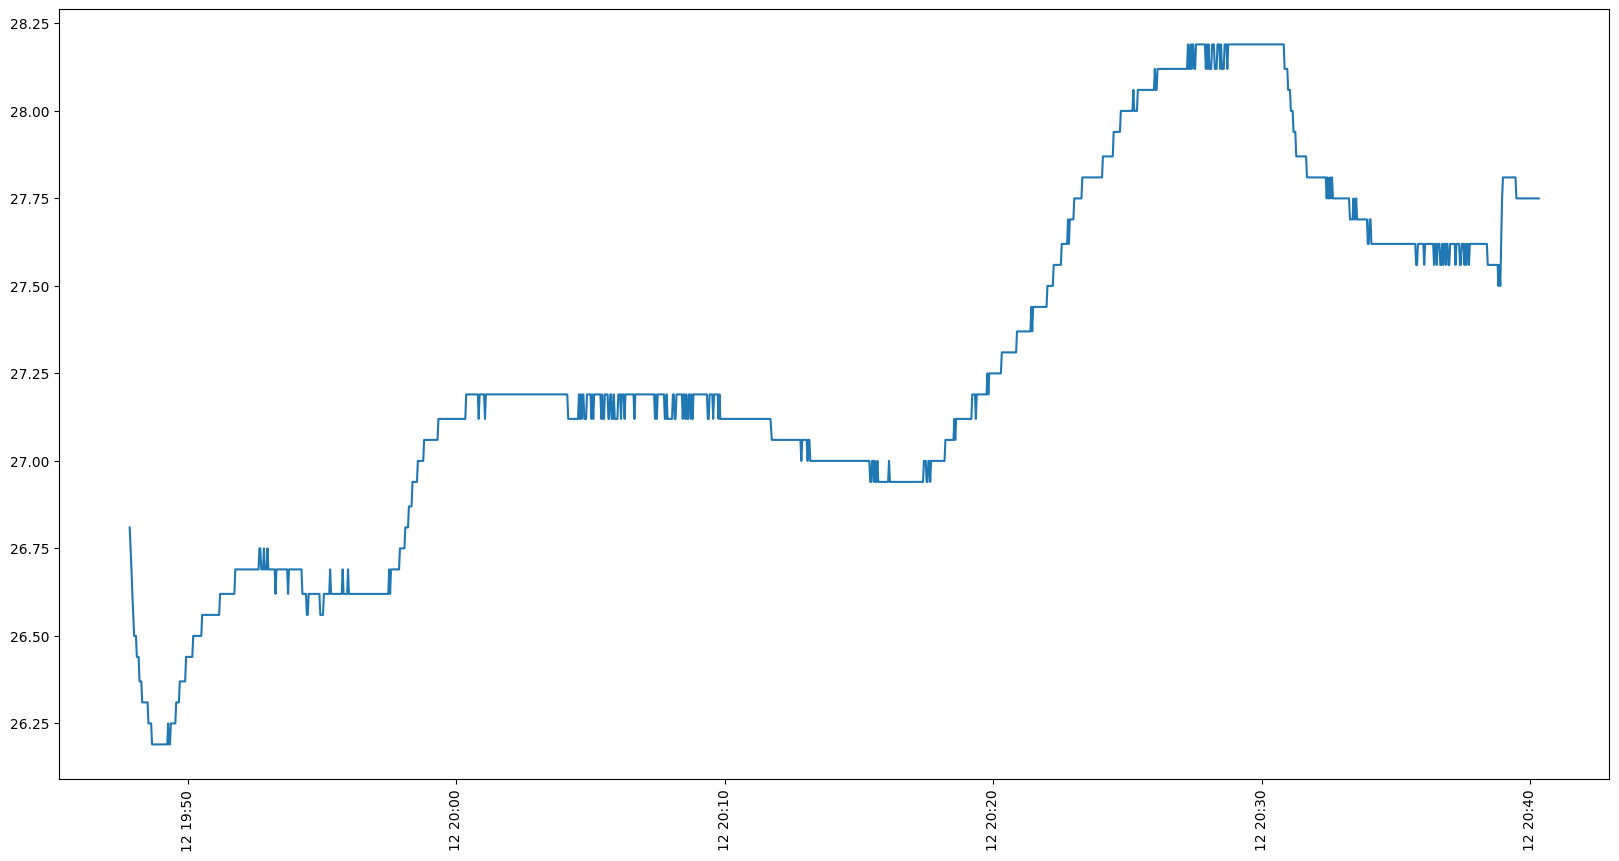

In [6]:
df['Time'] = pd.to_datetime(df['Time'], dayfirst=True)

plt.figure(figsize=(20, 10))
plt.plot(df['Time'], df['Temperature (C)'])
plt.xticks(rotation='vertical')
plt.show()

In [9]:
# We group data by 10 mins block
df['10min_block'] = df['Time'].dt.floor('10min')
data_by_block = df.groupby('10min_block')

In [10]:
# Find max and min of 10-min block
min_by_block = data_by_block['Temperature (C)'].min()
max_by_block = data_by_block['Temperature (C)'].max()

In [11]:
# Join the min and max temperatures into one dataframe and flatten it.
min_max_df = pd.concat([min_by_block, max_by_block], axis=1)
min_max_df.columns = ['temp_min', 'temp_max']
min_max_df = min_max_df.reset_index()

In [ ]:
def calculate_gdd(row):
    avg_temp = (row['temp_max'] + row['temp_min']) / 2
    gdd = avg_temp - base_temperature
    return max(gdd, 0)

min_max_df['gdd'] = min_max_df.apply(calculate_gdd, axis=1)

In [13]:
# Print the result
print(min_max_df[['10min_block', 'gdd']].to_string(index=False))

        10min_block    gdd
2026-04-12 19:40:00 16.500
2026-04-12 19:50:00 16.780
2026-04-12 20:00:00 17.155
2026-04-12 20:10:00 17.095
2026-04-12 20:20:00 17.720
2026-04-12 20:30:00 17.845
2026-04-12 20:40:00 17.750
